# Cinema Attendance and Ticket Prices in Germany: An Exploratory Data Analysis

**Author:** Federico Bonato  
**Date:** April 2025


## Introduction

This project explores cinema attendance patterns and ticket pricing across different federal states of Germany over time.  
The analysis aims to answer key questions regarding how cinema habits and infrastructure vary geographically and temporally,
and whether economic factors like ticket prices are correlated with audience behavior.

---

## Research Questions

1. **Evolution of Ticket Prices:**  
   How has the average cinema ticket price evolved over the years across different German states?

2. **Cinema Attendance Patterns:**  
   Which federal states have seen the highest and lowest number of cinema visits per inhabitant over time?

3. **Ticket Price vs. Attendance:**  
   Is there a relationship between average ticket prices and the number of cinema visits per inhabitant in each state?

4. **Infrastructure vs. Attendance:**  
   How does the number of cinemas and screens in a region relate to the number of cinema visitors?

5. **Seating Capacity vs. Attendance:**  
   How does the number of cinema seats in a region relate to visits per inhabitant? Does higher seating capacity correspond to higher attendance rates?

---

## Suitable Analysis Methods

To investigate these questions, the following visual and statistical methods will be applied:

- **Line Plot:**  
  To visualize the development of average ticket prices over time per state.

- **Bar Plot / Heatmap:**  
  To compare cinema visits per inhabitant across states and years.

- **Scatter Plot:**  
  To explore relationships between average ticket prices, cinema visits, number of cinemas/screens, and population.

---

## Let's proceed with the code:

## 1. Import relevant libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from plot_polynomial_trends import plot_polynomial_trends

## 2. Data Loading and Initial Inspection

The data is loaded from '../data/21611-0003_en.csv'.

 **Data source:**  
This dataset was retrieved from the official portal of the German Federal Statistical Office:  
[GENESIS-Online, Destatis](https://www-genesis.destatis.de/datenbank/online/)



In [3]:
# Load the dataset
df = pd.read_csv('../data/21611-0003_en.csv', delimiter=';')

# Display basic information about the dataset
print("Dataset Overview:")
print("-----------------")
print("\nDataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
display(df.head())

# Print list of regions
regions = df['Regions']
print("Regions included:\n", sorted(regions.unique()))

# Print range of years
years = df['Years']
print("\nYears covered:\n", sorted(years.unique()))


Dataset Overview:
-----------------

Dataset shape: (404, 9)

Columns: ['Regions', 'Years', 'Cinemas', 'Screens', 'Cinema seats', 'Cinema visits', 'Cinema visits per inhabitant', 'Average cinema ticket price', 'Gross receipts from cinema visits']

First few rows:


,Regions,Years,Cinemas,Screens,Cinema seats,Cinema visits,Cinema visits per inhabitant,Average cinema ticket price,Gross receipts from cinema visits
0,Baden-Württemberg,2000.0,258.0,626.0,110626.0,18.5,1.8,5.57,103.2
1,Baden-Württemberg,2001.0,249.0,621.0,110251.0,22.4,2.1,5.67,127.2
2,Baden-Württemberg,2002.0,252.0,629.0,109265.0,21.3,2.0,5.89,125.3
3,Baden-Württemberg,2003.0,262.0,656.0,111429.0,19.3,1.8,5.79,112.1
4,Baden-Württemberg,2004.0,260.0,656.0,112175.0,20.8,1.9,5.81,120.6


Regions included:
 ['Baden-Württemberg', 'Bayern', 'Berlin', 'Brandenburg', 'Bremen', 'Hamburg', 'Hessen', 'Mecklenburg-Vorpommern', 'Niedersachsen', 'Nordrhein-Westfalen', 'Rheinland-Pfalz', 'Saarland', 'Sachsen', 'Sachsen-Anhalt', 'Schleswig-Holstein', 'Source:\nGerman Federal Film Board, Berlin\n\nCinema seats:\n2000-2011: Seats excluding open-air, university cinemas and \nclosures. \nFrom 2012: Seats excluding open-air, university cinemas, \nfilm festivals and closures.\n\nAverage cinema ticket price:\nGross prices.\n\n2019: \nDue to a changed allocation in the area of traveling\ncinemas, there is a disproportionate increase in the \nfigures for cinemas, screens and cinema seats.', 'Thüringen', '__________', 'created: 2025-04-21 / 10:52:10', '© Statistisches Bundesamt (Destatis), 2025']

Years covered:
 [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022

The dataset consists of **yearly cinema-related statistics** across the 16 German federal states from **2000 to 2024**. Each row represents a combination of a state and a year.

**Regions included:**
- Baden-Württemberg
- Bayern
- Berlin
- Brandenburg
- Bremen
- Hamburg
- Hessen
- Mecklenburg-Vorpommern
- Niedersachsen
- Nordrhein-Westfalen
- Rheinland-Pfalz
- Saarland
- Sachsen
- Sachsen-Anhalt
- Schleswig-Holstein
- Thüringen

**Years covered:**
- 2000 to 2024 (25 years)

**Indicators available:**
- Total cinemas
- Total screens
- Total seats
- Total visits
- Visits per capita
- Average ticket price (EUR)
- Total revenue (EUR)

## 3. Data Cleaning:

After the step 2 i have realized that at least exist a `NaN` value.
For this reason, before starting my analysis, I would proceed with a few essential data cleaning steps to ensure consistency and readability:

- The `Year` column was initially stored as float values (e.g., `2000.0`). Since years are discrete entities, I converted them to integers.
- I noticed that one row had a missing value (`NaN`) in the `Year` column. Since each entry in the dataset should correspond to a valid year and region, I exclude this row.
- To avoid inconsistencies during the analysis, I also look for any remaining rows that contained missing values in any other column and keep it out.

These operations help ensure that the dataset is clean, well-structured, and ready for further exploration.

In [4]:
#1. Check for NaN values in the dataframe:

print("NaN values per column:")
nan_values = df.isna().sum()
print(nan_values)

# Drop NaN values and create clean dataframe
df_clean = df.dropna()

print("------- After cleaning -------")
print(f"Total rows: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

# Update the original dataframe
df = df_clean

#2. # Convert Years column to integer type
df['Years'] = df['Years'].astype(int)
years = df['Years']
print("Years data type after conversion:", df['Years'].dtype)


NaN values per column:
Regions                              0
Years                                4
Cinemas                              4
Screens                              4
Cinema seats                         4
Cinema visits                        4
Cinema visits per inhabitant         4
Average cinema ticket price          4
Gross receipts from cinema visits    4
dtype: int64
------- After cleaning -------
Total rows: 400
Rows removed: 4
Years data type after conversion: int64


Now everytime i refer to `df`, it will be the cleaned version. 
As expected the number of removed rows is the same of the NaN values.
This guarantees that the data is clean and ready for analysis.

### 3.1 Creating Data Structures for Analysis

Before diving into our analysis questions, let's create some useful data structures that will help us maintain consistency throughout our exploration:

- **Regional Data Dictionary**: A dictionary containing separate dataframes for each federal state, allowing easy access to region-specific data


These structures will help us:
- Maintain consistent analysis across all research questions
- Ensure visual consistency in our plots
- Make our code more efficient and readable
- Reduce redundancy in our analysis

In [5]:
# Create dictionary of regional dataframes
regional_data = {
    region: df[df['Regions'] == region].copy().sort_values('Years') 
    for region in sorted(df['Regions'].unique())
}


## 4. Data Analysis and Visualization

### Question number 1: Evolution of Ticket Prices

Let's analyze how average cinema ticket prices have changed over time across different German states:
- Plot the trend of average ticket prices for all states
- Identify states with highest and lowest price increases
- Calculate the overall price change percentage from 2000 to 2024

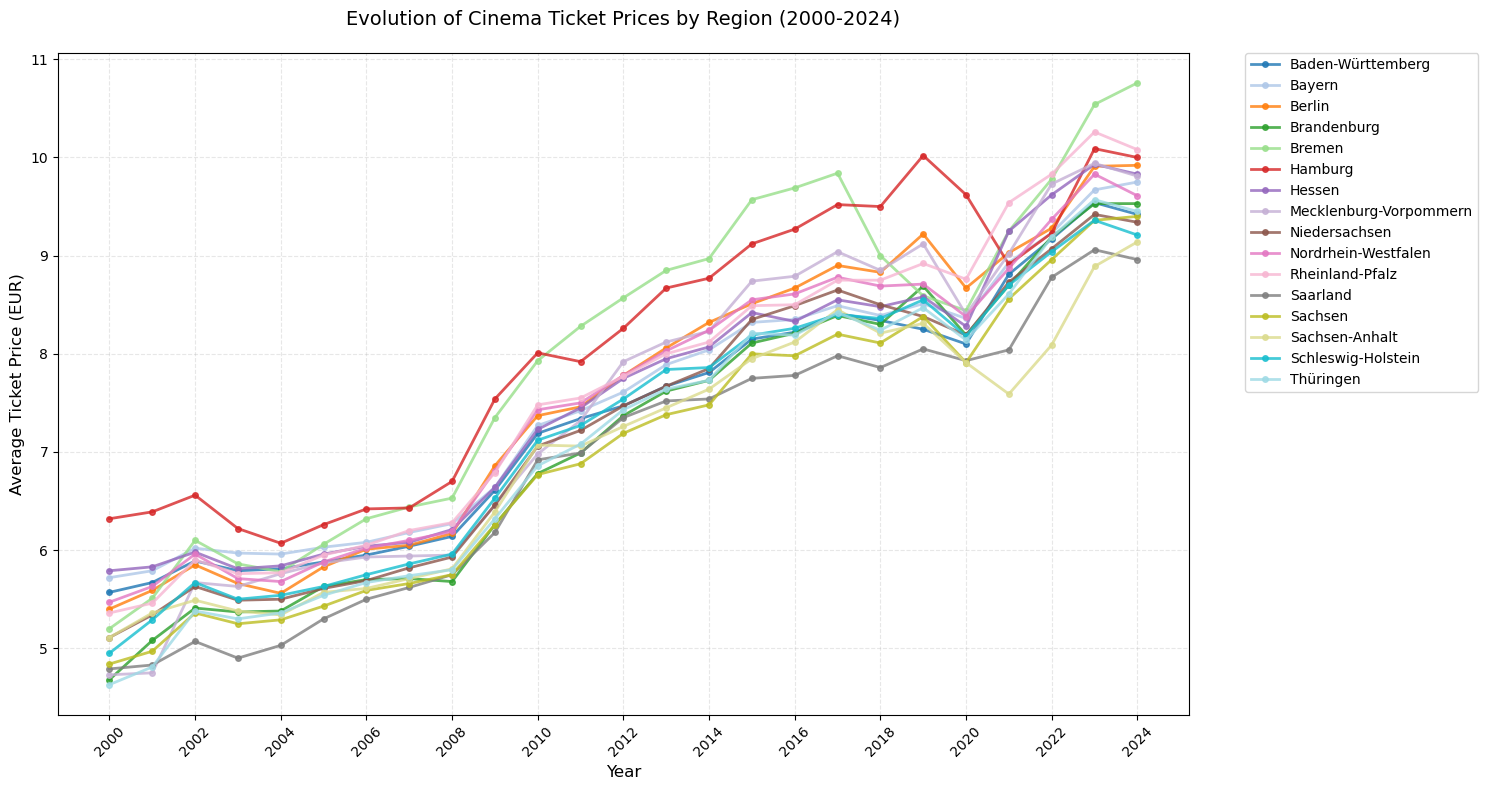

In [6]:
################################################################################
# 4.1: Plot the trend of average ticket prices for all states

# Set up the figure size
plt.figure(figsize=(15, 8))

# Create color map for regions
colors = plt.cm.tab20(np.linspace(0, 1, len(regional_data)))
region_colors = dict(
    zip(sorted(regional_data.keys()), colors)
)

# Plot each region's price evolution
for region, data in regional_data.items():
    plt.plot(
        data['Years'],
        data['Average cinema ticket price'],
        marker='o',
        markersize=4,
        linewidth=2,
        label=region,
        color=region_colors[region],
        alpha=0.8
    )

# Customize the plot
plt.title(
    'Evolution of Cinema Ticket Prices by Region (2000-2024)',
    fontsize=14,
    pad=20
)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Ticket Price (EUR)', fontsize=12)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.3)

# Customize legend
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=10
)

# Customize x-axis
plt.xticks(
    sorted(df['Years'].unique())[::2],
    rotation=45
)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

## 4.1: Let's check and plot which is the plynomial that represent better the trend of this evolution:

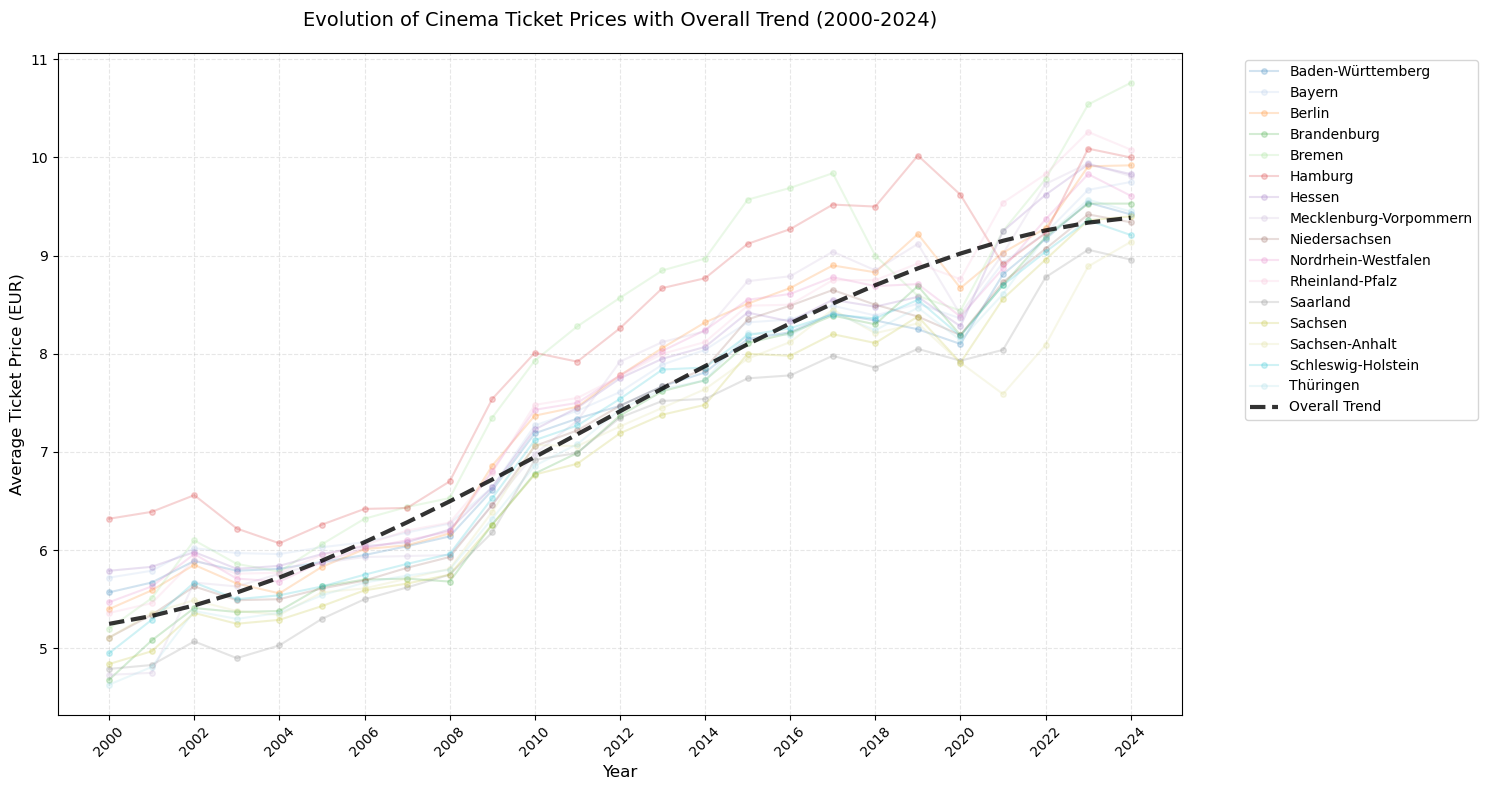

In [13]:
# Plot ticket prices evolution with polynomial trend
plt.figure(figsize=(15, 8))

# Plot individual lines with low opacity
for region, data in regional_data.items():
    plt.plot(
        data['Years'],
        data['Average cinema ticket price'],
        marker='o',
        markersize=4,
        linewidth=1.5,
        color=region_colors[region],
        alpha=0.2,
        label=(region)
    )

# Add polynomial trend
plot_polynomial_trends(
    data_groups=[df],
    column_name='Average cinema ticket price',
    years=sorted(df['Years'].unique()),
    colors=['black'],
    labels=['Overall Trend'],
    title='Evolution of Cinema Ticket Prices with Overall Trend (2000-2024)'
)

# Customize plot
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Ticket Price (EUR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(sorted(df['Years'].unique())[::2], rotation=45)
plt.tight_layout()
plt.show()

### Analysis of the Polynomial Trend

**Key Findings**:
   - The trend shows a clear non-linear increase in ticket prices over time
   - The rate of price increase has not been constant
   - There's evidence of price growth moderation in recent years
   - The model suggests a possible plateau effect in future prices

This polynomial fit helps us understand that cinema ticket prices haven't simply increased linearly, but have followed a more complex pattern of acceleration and deceleration over the studied period (a notable disruption occurred in 2020 (COVID-19 pandemic), followed by  a steeper price increase across all regions)

### 4.1 Analyzing Price Changes (2000-2024)

Let's identify:
1. States with the highest and lowest price increases
2. Overall price change across all regions

In [8]:
################################################################################
# 4.1: Calculate price changes for each region
price_changes = {}
for region, data in regional_data.items():
    initial_price = data.iloc[0]['Average cinema ticket price']
    final_price = data.iloc[-1]['Average cinema ticket price']
    pct_change = ((final_price - initial_price) / initial_price) * 100
    price_changes[region] = pct_change

# Convert to Series:
changes = pd.Series(price_changes).round(2)

# Get Hamburg's data from the regional_data dictionary:
hamburg_data = regional_data['Hamburg']
hamburg_min = hamburg_data['Average cinema ticket price'].min()
hamburg_max = hamburg_data['Average cinema ticket price'].max()

# Get Mecklenburg-Vorpommern's data from the regional_data dictionary:
mecklenburg_data = regional_data['Mecklenburg-Vorpommern']
mecklenburg_min = mecklenburg_data['Average cinema ticket price'].min()
mecklenburg_max = mecklenburg_data['Average cinema ticket price'].max()

print(f"Minimum increase: +{changes.min()}% ({changes.idxmin()})")
print(f'From: {hamburg_min} -> to {hamburg_max}')
print(f"Maximum increase: +{changes.max()}% ({changes.idxmax()})")
print(f'From: {mecklenburg_min} -> to {mecklenburg_max}')
# Plot the price changes




Minimum increase: +58.23% (Hamburg)
From: 6.07 -> to 10.09
Maximum increase: +107.4% (Mecklenburg-Vorpommern)
From: 4.73 -> to 9.94


## Question 2: Cinema Attendance Patterns

### 4.2 Evolution of Cinema Visits per Capita

Let's analyze how cinema attendance has changed over time across different German states by:
1. Plotting attendance trends for all states
2. Identifying regions with highest and lowest attendance


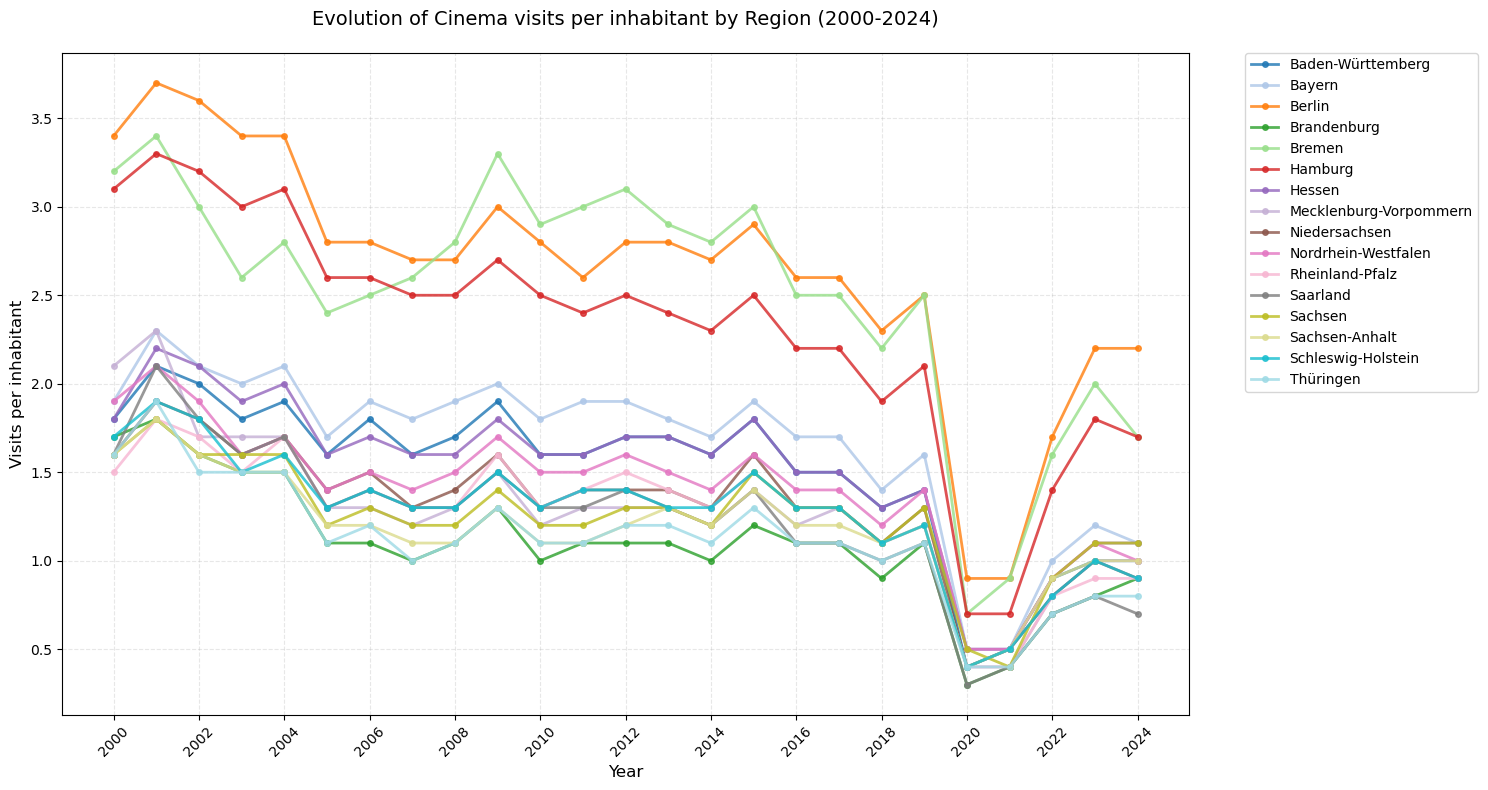

In [9]:
################################################################################
# 4.2: Plot the trend of cinema visits per capita for all states
''' Using the same color map (region_colors) and regional data dictionary
 created in section 4.1 for consistency across visualizations'''

# Set up the figure size
plt.figure(figsize=(15, 8))

# Plot each region's attendance evolution (using existing color map)
for region, data in regional_data.items():
    plt.plot(
        data['Years'],
        data['Cinema visits per inhabitant'],
        marker='o',
        markersize=4,
        linewidth=2,
        label=region,
        color=region_colors[region],
        alpha=0.8
    )

# Customize the plot
plt.title(
    'Evolution of Cinema visits per inhabitant by Region (2000-2024)',
    fontsize=14,
    pad=20
)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Visits per inhabitant', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=10
)
plt.xticks(
    sorted(df['Years'].unique())[::2],
    rotation=45
)
plt.tight_layout()
plt.show()


### Key Observations from Cinema Attendance Patterns:

1. **COVID-19 Impact (2020-2021):**  
   The data shows a dramatic and uniform decline in cinema attendance across all regions during the COVID-19 pandemic, with visits per capita dropping to historically low levels. This represents the most significant disruption in the observed period (2000-2024).

2. **City-States vs. Other Regions:**  
   A striking pattern emerges when comparing city-states (Berlin, Hamburg, Bremen) with other federal states. City-states consistently show higher visits per capita. This notable difference warrants a focused analysis in the next step.

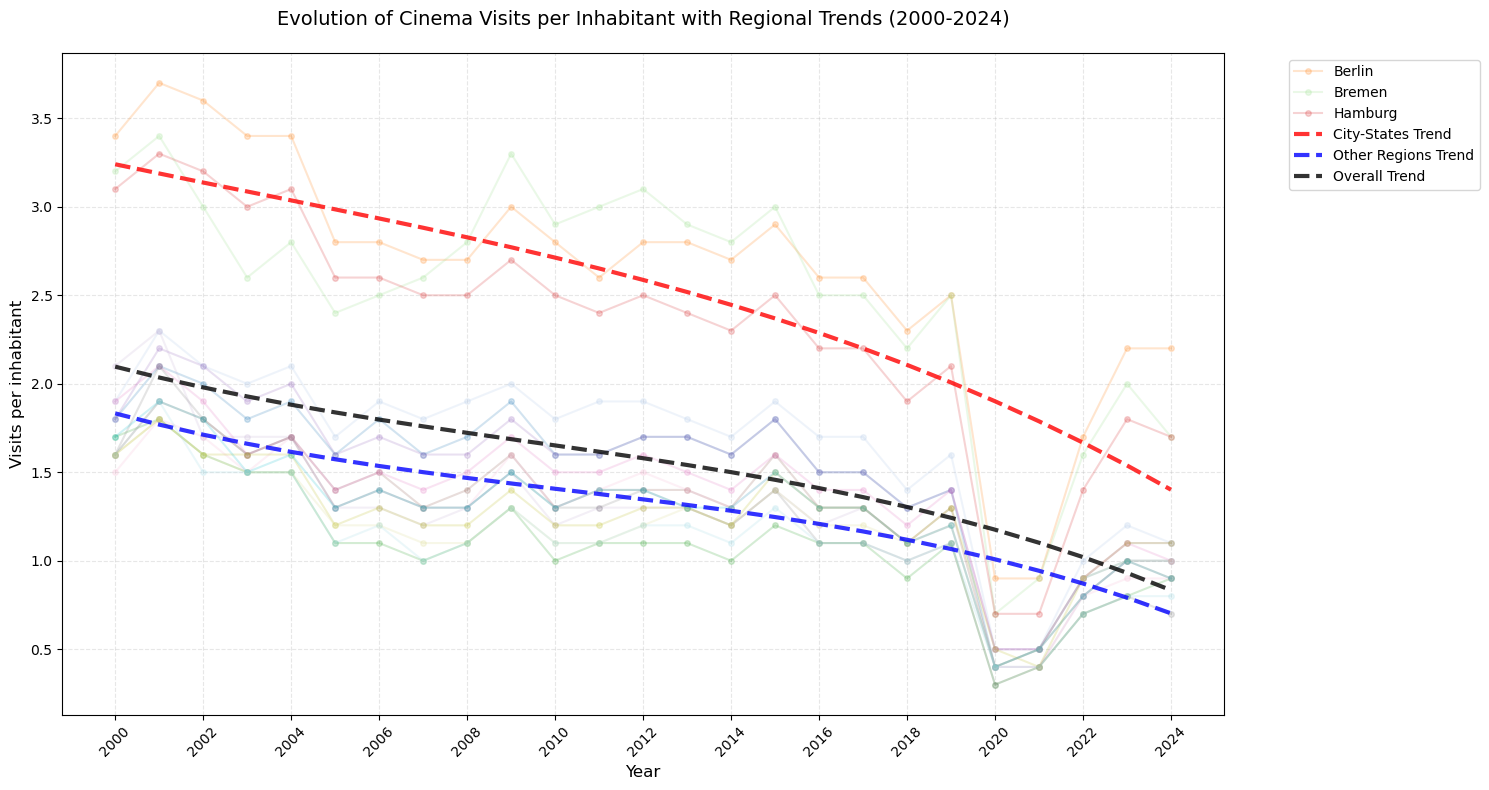

In [10]:
'''Let's plot the trend of cinema visits per inhabitants with polynomial trend lines.
I expect to see a difference between city-states and other regions.
At the same time the overall trend it supposed to be closer to the trend of non-city-states.'''


# Set up the figure size
plt.figure(figsize=(15, 8))

# Define city-states and other regions
city_states = ['Berlin', 'Hamburg', 'Bremen']
other_regions = [region for region in df['Regions'].unique() if region not in city_states]

# Create DataFrames for each group
city_states_df = df[df['Regions'].isin(city_states)]
other_regions_df = df[df['Regions'].isin(other_regions)]

# Plot individual lines
for region, data in regional_data.items():
    plt.plot(
        data['Years'],
        data['Cinema visits per inhabitant'],
        marker='o',
        markersize=4,
        linewidth=1.5,
        color=region_colors[region],
        alpha=0.2,
        label=region if region in city_states else ""
    )

# Add polynomial trends for all three cases
plot_polynomial_trends(
    data_groups=[city_states_df, other_regions_df, df],
    column_name='Cinema visits per inhabitant',
    years=sorted(df['Years'].unique()),
    colors=['red', 'blue', 'black'],
    labels=['City-States Trend', 'Other Regions Trend', 'Overall Trend'],
    title='Evolution of Cinema Visits per Inhabitant with Regional Trends (2000-2024)'
)

# Customize plot
plt.xlabel('Year', fontsize=12)
plt.ylabel('Visits per inhabitant', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(sorted(df['Years'].unique())[::2], rotation=45)
plt.tight_layout()
plt.show()

### 4.2 Analyzing Regional Attendance Patterns (Excluding COVID-19 Period)

To get a more representative picture of typical cinema attendance patterns across regions, I'll analyze the data excluding the years 2020-2021, when the COVID-19 pandemic significantly disrupted normal cinema operations. This approach will:

1. **Provide More Representative Patterns:**  
   By excluding the pandemic period, we can better understand the typical attendance differences between regions.

2. **Allow Fair Comparisons:**  
   Since different regions may have had varying COVID-19 restrictions, excluding these years ensures more comparable data.

In [11]:
#################################################################################
''' Calculate average attendance per inhabitants for each region
The idea is to exclude the years 2020 and 2021 due to COVID-19
So i will create a new DataFrame for each region excluding these years and then calculate the average, max and min attendance
Create a dictionary to store attendance statistics
for each region '''

attendance_stats = {}
for region, data in regional_data.items():
    non_covid_data = data[~data['Years'].isin([2020, 2021])]
    avg_attendance = non_covid_data['Cinema visits per inhabitant'].mean()
    max_attendance = non_covid_data['Cinema visits per inhabitant'].max()
    min_attendance = non_covid_data['Cinema visits per inhabitant'].min()
    attendance_stats[region] = {
        'average': avg_attendance,
        'max': max_attendance,
        'min': min_attendance
    }

# Convert to DataFrame:
stats_df = pd.DataFrame.from_dict(attendance_stats, orient='index')
stats_df = stats_df.round(2)

# Sort by average attendance
stats_df = stats_df.sort_values('average', ascending=False)

print("Cinema Attendance Statistics (excluding COVID years 2020-2021):")
print("----------------------------------------------------------")
print("Top 3 regions by average visits per inhabitant:")
print(stats_df.head(3))
print("Bottom 3 regions by average visits per inhabitant:")
print(stats_df.tail(3))

# Print the overall range
highest_region = stats_df.index[0]
lowest_region = stats_df.index[-1]
print(f"\nAttendance Range:")
print(f"Highest average: {highest_region} ({stats_df.loc[highest_region, 'average']:.2f} visits/inhabitant)")
print(f"Lowest average: {lowest_region} ({stats_df.loc[lowest_region, 'average']:.2f} visits/inhabitant)")
print(f"Difference factor: {(stats_df.loc[highest_region, 'average'] / stats_df.loc[lowest_region, 'average']):.1f}x")

Cinema Attendance Statistics (excluding COVID years 2020-2021):
----------------------------------------------------------
Top 3 regions by average visits per inhabitant:
         average  max  min
Berlin      2.79  3.7  1.7
Bremen      2.67  3.4  1.6
Hamburg     2.46  3.3  1.4
Bottom 3 regions by average visits per inhabitant:
                average  max  min
Sachsen-Anhalt     1.25  1.8  0.9
Thüringen          1.19  1.9  0.7
Brandenburg        1.17  1.8  0.7

Attendance Range:
Highest average: Berlin (2.79 visits/inhabitant)
Lowest average: Brandenburg (1.17 visits/inhabitant)
Difference factor: 2.4x


### Summary of Regional Attendance Patterns:


Considering these last results, i find relevant and interesting for this research to investigate which could be the considerable resasons that lead to such gap between city-states and other regions. 
From this point, the next research questions are oriented on these aspects.

## Question 3: Ticket Price vs. Attendance:

In the first two questions i've researched how the averaged ticket price and attendance are distribuited in all the regions during the years.
I would like to see now if those carachteristics are correlated, and if this could in some way describe the differences between city-states and the other regions.

### 4.3 Analyzing Price-Attendance Relationship

To understand if there's a relationship between ticket prices and attendance, I'll conduct the analysis in two steps:

1. **Overall Relationship Analysis:**
   - Create a scatter plot using all data points across all regions
   - Calculate the Spearman correlation coefficient for the entire dataset
   - This will give a general understanding of whether higher ticket prices tend to correspond with higher or lower attendance

2. **City-States Focus:**
   - Create a separate scatter plot focusing only on city-states (Berlin, Hamburg, Bremen)
   - Calculate the Spearman correlation coefficient for city-states specifically
   - This will help to understand if the price-attendance relationship differs in urban centers

This two-step approach will help to identify whether the relationship between prices and attendance is consistent across all regions or if it shows different patterns in city-states.

### (Why Use Spearman Correlation?)

In this analysis, I aim to study the relationship between average cinema ticket prices and cinema visits per inhabitant. However, due to the potential influence of various external factors (e.g., cultural changes, the rise of streaming platforms, or economic shifts), the relationship between these variables may not be strictly linear. 

For this reason, I have chosen to use **Spearman's rank correlation**. Spearman correlation is particularly useful because:
- It measures the **monotonic relationship** between two variables, rather than assuming a linear relationship.
- It is **less sensitive to outliers**.
- It focuses on the **rank order** of the data, making it more robust when the data contains non-linear trends.

By using Spearman correlation, I can better capture the underlying monotonic trends between ticket prices and attendance, even if the relationship is not perfectly linear.

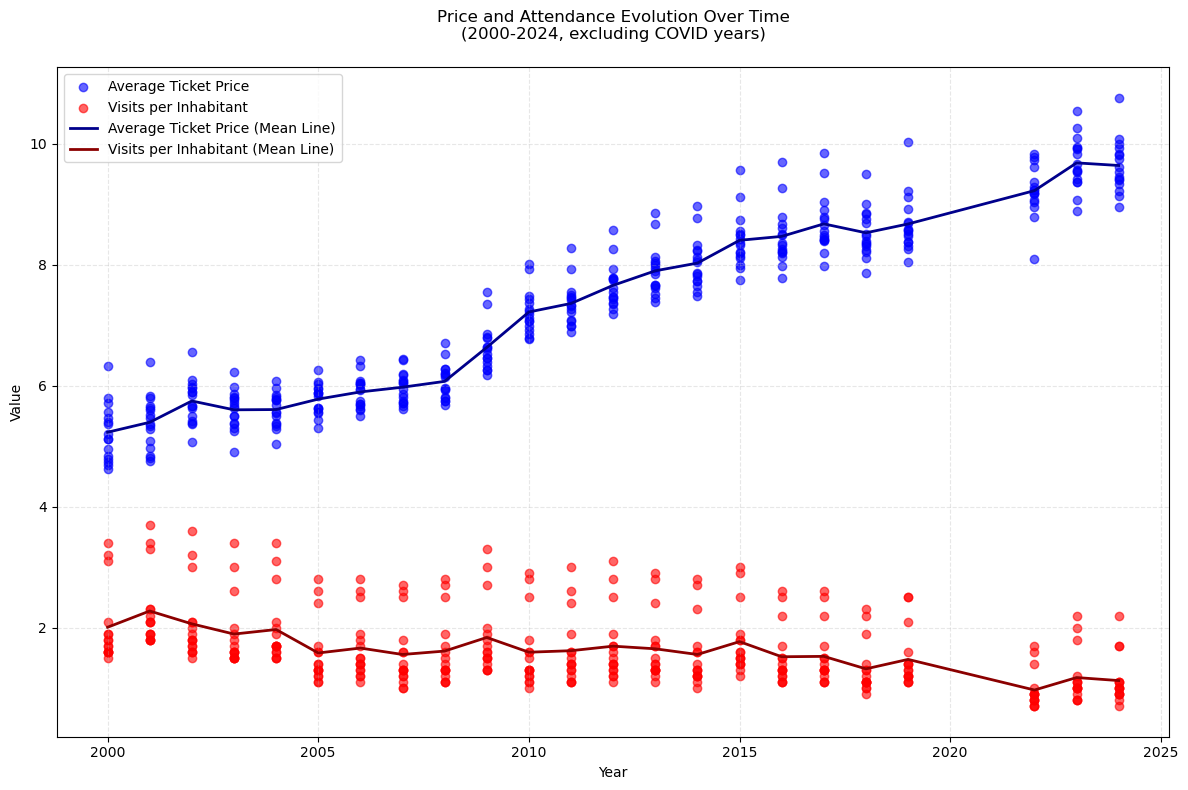

In [14]:
# Recall data
non_covid_data = df[~df['Years'].isin([2020, 2021])]
prices = non_covid_data['Average cinema ticket price']
attendance = non_covid_data['Cinema visits per inhabitant']

# Calculate mean values for each year
mean_prices_per_year = non_covid_data.groupby('Years')['Average cinema ticket price'].mean()
mean_attendance_per_year = non_covid_data.groupby('Years')['Cinema visits per inhabitant'].mean()

# Plot the scatter plot with Spearman correlation
plt.figure(figsize=(12, 8))

# Plot price points
plt.scatter(non_covid_data['Years'], 
           prices,
           color='blue',
           alpha=0.6,
           label='Average Ticket Price')

# Plot attendance points
plt.scatter(non_covid_data['Years'],
           attendance,
           color='red',
           alpha=0.6,
           label='Visits per Inhabitant')

# Plot mean lines
plt.plot(mean_prices_per_year.index, 
         mean_prices_per_year.values, 
         color='#00008B', 
         linestyle='-', 
         linewidth=2, 
         label='Average Ticket Price (Mean Line)')

plt.plot(mean_attendance_per_year.index, 
         mean_attendance_per_year.values, 
         color='#8B0000', 
         linestyle='-', 
         linewidth=2, 
         label='Visits per Inhabitant (Mean Line)')

# Customize plot
plt.title('Price and Attendance Evolution Over Time\n(2000-2024,' \
' excluding COVID years)',
         pad=20)
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Calculate Spearman correlation
spearman_correlation = stats.spearmanr(
    non_covid_data['Average cinema ticket price'],
    non_covid_data['Cinema visits per inhabitant']
)

# Extract Spearman correlation coefficient and p-value
spearman_r_value = spearman_correlation.correlation
spearman_p_value = spearman_correlation.pvalue

# Print the results
print("Spearman Correlation Analysis:")
print("-----------------------------")
print(f"Spearman correlation coefficient (r): {spearman_r_value:.3f}")
print(f"P-value: {spearman_p_value:.3f}")

# Interpretation
if spearman_r_value < 0:
    print("The correlation coefficient is slightly negative, "
    "indicating a weak tendency toward anticorrelation.")
else:
    print("The correlation coefficient is positive, " \
    "indicating a weak tendency toward correlation.")

if spearman_p_value < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")

Spearman Correlation Analysis:
-----------------------------
Spearman correlation coefficient (r): -0.319
P-value: 0.000
The correlation coefficient is slightly negative, indicating a weak tendency toward anticorrelation.
The correlation is statistically significant.


### Analysis of the Relationship Between Ticket Prices and Attendance

The scatterplot visualizes the relationship between **Average Cinema Ticket Price** and **Cinema Visits per Inhabitant** over time. Each point represents the values for a specific year, while the mean lines for both attributes highlight the overall trends.

#### Spearman Correlation Results:
- **Spearman Correlation Coefficient (r):** The calculated value of `r` is slightly negative and close to 0, indicating a weak tendency toward anticorrelation between ticket prices and attendance.
- **P-value:** The p-value is very small (e.g., `< 0.05`), suggesting that the observed correlation is statistically significant.

#### Visual Insights:
- The scatterplot shows the distribution of data points over time, with blue dots representing ticket prices and red dots representing attendance.
- The mean lines (dark blue for ticket prices and dark red for attendance) provide a clearer view of the overall trends for each attribute, helping to identify patterns over the years.

#### Interpretation:
- The weak anticorrelation suggests that as ticket prices increase, there is a slight tendency for attendance to decrease. However, this relationship is not strong, indicating that other factors (e.g., cultural shifts, streaming platforms, or regional differences) likely play a significant role in influencing attendance.
- The statistical significance of the p-value confirms that the observed relationship is unlikely to be due to random chance.
- It's still slightly observable how the average ticket prices increase during the time whereas the attendance values are slowly decreasing.

#### - Let's repeat the same analysis for the subset of the city-states:
The aim is to investigate and see if in these contexts the trend is different.

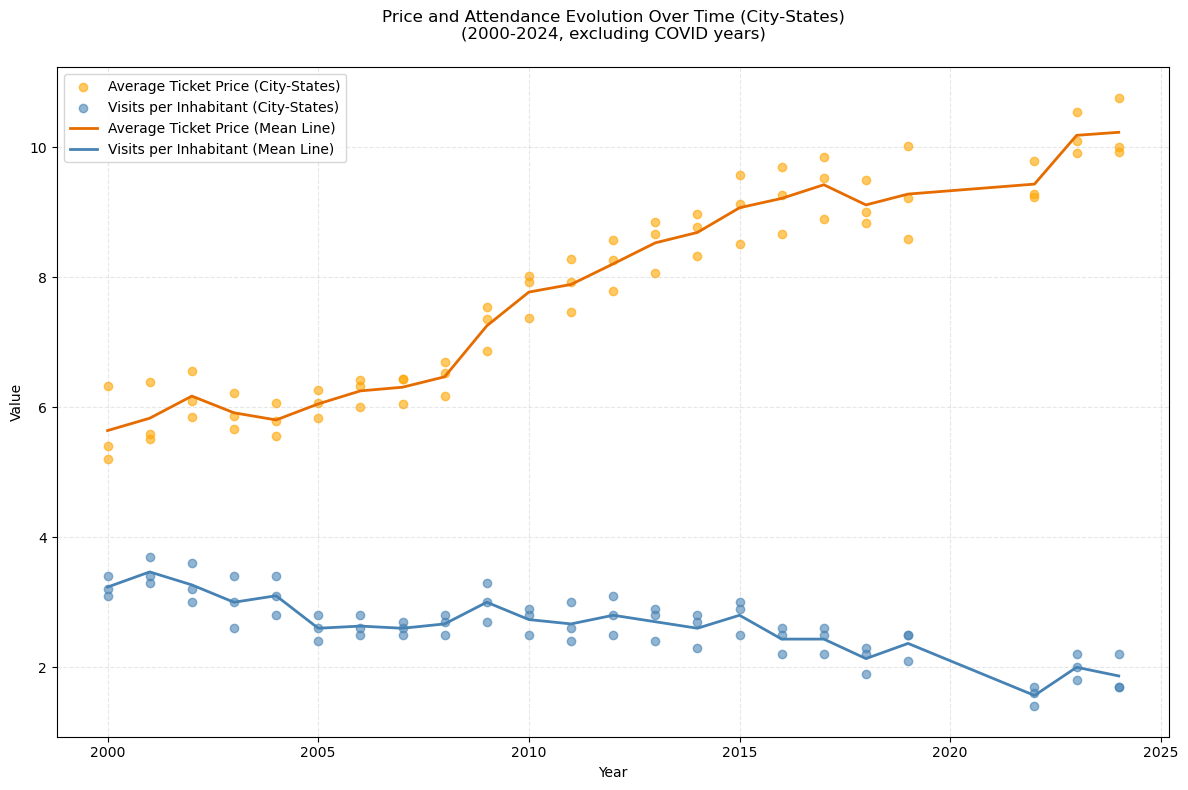

In [ ]:
# Recall data for city-states
city_states = ['Berlin', 'Hamburg', 'Bremen']
city_states_data = non_covid_data[non_covid_data['Regions'].isin(city_states)]
prices_city = city_states_data['Average cinema ticket price']
attendance_city = city_states_data['Cinema visits per inhabitant']

# Calculate mean values for each year
mean_prices_city_per_year = city_states_data.groupby('Years')['Average cinema ticket price'].mean()
mean_attendance_city_per_year = city_states_data.groupby('Years')['Cinema visits per inhabitant'].mean()

# Plot the scatter plot
plt.figure(figsize=(12, 8))

# Plot price points
plt.scatter(city_states_data['Years'], 
           prices_city,
           color='#FFA500',  # Orange
           alpha=0.6,
           label='Average Ticket Price (City-States)')

# Plot attendance points
plt.scatter(city_states_data['Years'],
           attendance_city,
           color='#4682B4',  # Light blue
           alpha=0.6,
           label='Visits per Inhabitant (City-States)')

# Plot mean lines
plt.plot(mean_prices_city_per_year.index, 
         mean_prices_city_per_year.values, 
         color='#E66C00',  # Darker orange
         linestyle='-', 
         linewidth=2, 
         label='Average Ticket Price (Mean Line)')

plt.plot(mean_attendance_city_per_year.index, 
         mean_attendance_city_per_year.values, 
         color='#4682B4',  # Darker blue
         linestyle='-', 
         linewidth=2, 
         label='Visits per Inhabitant (Mean Line)')

# Customize plot
plt.title('Price and Attendance Evolution Over Time (City-States)\n(2000-2024, excluding COVID years)',
         pad=20)
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
# Calculate Spearman correlation for city-states
city_states_correlation = stats.spearmanr(
    city_states_data['Average cinema ticket price'],
    city_states_data['Cinema visits per inhabitant']
)

# Extract Spearman correlation coefficient and p-value
city_states_r_value = city_states_correlation.correlation
city_states_p_value = city_states_correlation.pvalue

# Print the results
print("Spearman Correlation Analysis (City-States):")
print("------------------------------------------")
print(f"Spearman correlation coefficient (r): {city_states_r_value:.3f}")
print(f"P-value: {city_states_p_value:.3f}")

# Interpretation
if city_states_r_value < 0:
    print("The correlation coefficient is negative, indicating a tendency toward anticorrelation.")
else:
    print("The correlation coefficient is positive, indicating a tendency toward correlation.")

if city_states_p_value < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")

# Compare with overall correlation
print("\nComparison with Overall Correlation:")
print(f"City-States: r = {city_states_r_value:.3f}, Overall: r = {spearman_r_value:.3f}")

Spearman Correlation Analysis (City-States):
------------------------------------------
Spearman correlation coefficient (r): -0.725
P-value: 0.000
The correlation coefficient is negative, indicating a tendency toward anticorrelation.
The correlation is statistically significant.

Comparison with Overall Correlation:
City-States: r = -0.725, Overall: r = -0.319


### Spearman Correlation Results for City-States Analysis


- **Stronger Negative Correlation**: City-states exhibit a much stronger negative correlation (-0.725) between ticket prices and attendance compared to the overall dataset (-0.319). This correlation is more than twice as strong in magnitude.

- **Statistical Significance**: The p-value of nearly zero confirms that this relationship is highly unlikely to be due to random chance.

- **Price Sensitivity**: The strong negative correlation suggests that cinema attendance in city-states (Berlin, Hamburg, Bremen) is considerably more price-sensitive than in other regions. As ticket prices increase, there is a more pronounced tendency for attendance to decrease in these urban centers.

This contrast in correlation strength helps explain some of the distinct attendance patterns observed between city-states and other federal states of Germany.